# 8-2 안정적으로 더 깊게 쌓기 - 배치 정규화

본 노트북은 8-2 절 본문의 [코드 8-3]~[코드 8-10] 예제를 포함한다. 배치 정규화를 추가한 `MiniVGGNetBN` 모델을 만들고, 파이토치 훅으로 순전파·역전파 과정을 직접 들여다본다.

다루는 내용
- `[코드 8-3]`·`[코드 8-4]` 배치 정규화를 더한 `MiniVGGNetBN` 클래스와 정보
- `[표 8-3]` MiniVGGNet 과 MiniVGGNetBN 의 학습·평가 결과 비교
- `[코드 8-5]`~`[코드 8-8]` 순전파 훅으로 배치 정규화 전후 분포 관찰
- `[코드 8-9]`·`[코드 8-10]` 역전파 훅으로 기울기 신호 검사
- `[표 8-5]` 세 모델의 합성곱 계층 위치별 기울기 노름 비교

## 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)

In [1]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# !pip install -q numpy torch torchinfo torchvision

## 라이브러리 import 와 시드 고정

In [2]:
# 참고 - 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

In [3]:
# 참고 - 라이브러리 import 와 시드 고정
SEED = 42
common.set_seed(SEED, deterministic=True)
device = common.get_device()

CUDA를 사용합니다.


## 참고 - CIFAR-10 데이터로더 (8-1 절과 동일)

In [4]:
"""
# 참고 - CIFAR-10 데이터로더 (5-3 절과 동일, 데이터 증강 미적용)

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch

# data_root: 데이터셋 다운로드 경로
data_root = '../../download'

# 데이터 변환 객체
CIFAR_MEAN = (0.5, 0.5, 0.5)
CIFAR_STD = (0.5, 0.5, 0.5)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# 데이터셋 생성
#    CIFAR-10 데이터셋의 훈련 데이터셋(50,000 샘플)을 4:1로 훈련, 검증 데이터셋으로 분리
full_set = datasets.CIFAR10(
    root=data_root, train=True,
    download=True, transform=transform,
)
test_set = datasets.CIFAR10(
    root=data_root, train=False,
    download=True, transform=transform,
)

TRAIN_SIZE, VALID_SIZE = 40000, 10000
train_set, valid_set = random_split(
    full_set, [TRAIN_SIZE, VALID_SIZE],
    generator=torch.Generator().manual_seed(SEED),
)

# 배치 크기 128인 데이터로더 생성
BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'훈련/검증/평가 데이터셋: '
      f'{len(train_set)}/{len(valid_set)}/{len(test_set)}')
"""

"\n# 참고 - CIFAR-10 데이터로더 (5-3 절과 동일, 데이터 증강 미적용)\n\nfrom torchvision import datasets, transforms\nfrom torch.utils.data import DataLoader, random_split\nimport torch\n\n# data_root: 데이터셋 다운로드 경로\ndata_root = '../../download'\n\n# 데이터 변환 객체\nCIFAR_MEAN = (0.5, 0.5, 0.5)\nCIFAR_STD = (0.5, 0.5, 0.5)\ntransform = transforms.Compose([\n    transforms.ToTensor(),\n    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),\n])\n\n# 데이터셋 생성\n#    CIFAR-10 데이터셋의 훈련 데이터셋(50,000 샘플)을 4:1로 훈련, 검증 데이터셋으로 분리\nfull_set = datasets.CIFAR10(\n    root=data_root, train=True,\n    download=True, transform=transform,\n)\ntest_set = datasets.CIFAR10(\n    root=data_root, train=False,\n    download=True, transform=transform,\n)\n\nTRAIN_SIZE, VALID_SIZE = 40000, 10000\ntrain_set, valid_set = random_split(\n    full_set, [TRAIN_SIZE, VALID_SIZE],\n    generator=torch.Generator().manual_seed(SEED),\n)\n\n# 배치 크기 128인 데이터로더 생성\nBATCH_SIZE = 128\ntrain_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)\n

In [5]:
# 참고 - CIFAR-10 데이터로더 (5-3 절과 동일, 데이터 증강 적용)

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch

# data_root: 데이터셋 다운로드 경로
data_root = '../../download'

# 데이터 변환 객체
CIFAR_MEAN = (0.5, 0.5, 0.5)
CIFAR_STD = (0.5, 0.5, 0.5)

# 검증, 평가 데이터셋 데이터 변환 객체 (증강 없음)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# 훈련 데이터셋 데이터 변환 객체 (증강 추가)
train_transform = transforms.Compose([
    # 4 픽셀 패딩 후 32x32 크기로 무작위 자르기
    transforms.RandomCrop(32, padding=4),
    # 50% 확률로 좌우 반전
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# 데이터셋 생성
TRAIN_SIZE, VALID_SIZE = 40000, 10000       # 훈련/검증 데이터셋의 크기

# 같은 데이터셋으로 증강 변환 적용/미적용 데이터셋을 생성

# 증강 변환 적용: 훈련용으로 사용
train_full = datasets.CIFAR10(
    root=data_root, train=True,
    download=True, transform=train_transform,
)
# 증강 변환 미적용: 검증, 평가용으로 사용
valid_full = datasets.CIFAR10(
    root=data_root, train=True,
    download=True, transform=transform,
)

test_set = datasets.CIFAR10(
    root=data_root, train=False,
    download=True, transform=transform,
)

# 같은 기준으로 train_full과 valid_full을 분할해 훈련 데이터셋과 검증 데이터셋 생성
train_set, _ = random_split(train_full, [TRAIN_SIZE, VALID_SIZE], generator=torch.Generator().manual_seed(SEED))
# train_evaluate_set: 평가 시에는 증강 변환을 하지 않은 데이터셋 적용이 필요
train_evaluate_set, valid_set = random_split(valid_full, [TRAIN_SIZE, VALID_SIZE], generator=torch.Generator().manual_seed(SEED))

# 배치 크기 128인 데이터로더 생성
BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
train_evaluate_loader = DataLoader(train_evaluate_set, batch_size=BATCH_SIZE, shuffle=False)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'훈련/검증/평가 데이터셋: '
      f'{len(train_set)}/{len(valid_set)}/{len(test_set)}')

훈련/검증/평가 데이터셋: 40000/10000/10000


## 참고 - 비교용 모델 MiniVGGNet, MiniAlexNet (8-1 절)

In [6]:
# 참고 - 8-1 절 MiniVGGNet (배치 정규화 없음, 비교용)
import torch.nn as nn

class MiniVGGNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        def vgg_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2),
            )
        self.features = nn.Sequential(
            vgg_block(3, 32), vgg_block(32, 64), vgg_block(64, 128),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# 참고 - 8-1 절 MiniAlexNet (비교용)
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels,
                 kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(
                in_channels, out_channels, kernel_size, stride, padding,
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.conv_block(x)


class MiniAlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv_block_1 = ConvBlock(
            in_channels=3, out_channels=16,
            kernel_size=5, stride=1, padding=2,
        )
        self.conv_block_2 = ConvBlock(
            in_channels=16, out_channels=32,
            kernel_size=3, stride=1, padding=1,
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

## [코드 8-3] 배치 정규화 계층을 더한 MiniVGGNetBN 클래스

VGG 블록의 합성곱 계층 직후, 활성화 계층(ReLU) 이전에 배치 정규화 계층을 배치한다. 배치 정규화의 위치 파라미터(베타)가 편향을 대체하므로 합성곱은 `bias=False` 로 두고, 분류기의 드롭아웃은 제거한다.

In [7]:
###############################################################################
# 코드 8-3 - 배치 정규화 계층을 더한 MiniVGGNetBN 클래스
###############################################################################
import torch.nn as nn

# MiniVGGNetBN: 배치 정규화 계층을 추가한 합성곱 신경망 모델(CIFAR-10 분류)
#     VGG 블록의 구조: (합성곱 -> 배치 정규화 -> ReLU) * 2
class MiniVGGNetBN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 반복되는 VGG 블록을 만드는 헬퍼 함수 (내부 함수)
        def vgg_block(in_channels, out_channels):
            # 합성곱 계층과 활성화 계층 사이에 배치 정규화 계층 추가
            return nn.Sequential(
                # 배치 정규화의 베타 파라미터가 편향을 대체 (bias=False)
                nn.Conv2d(
                    in_channels, out_channels, kernel_size=3, padding=1,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),       # 추가된 배치 정규화 계층
                nn.ReLU(),
                nn.Conv2d(
                    out_channels, out_channels, kernel_size=3, padding=1,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),       # 추가된 배치 정규화 계층
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2),
            )
        # 특징 추출기 - VGG 블록을 반복해 배치
        self.features = nn.Sequential(
            vgg_block(3, 32),               # (3, 32, 32)  -> (32, 16, 16)
            vgg_block(32, 64),              #              -> (64, 8, 8)
            vgg_block(64, 128),             #              -> (128, 4, 4)
        )
        # 분류기 - 특징을 사용해 분류(드롭아웃 계층 제거)
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # (128, 4, 4)  -> (128 * 4 * 4,)
            nn.Linear(128 * 4 * 4, 128),    #              -> (128,)
            nn.ReLU(),
            nn.Linear(128, num_classes),    #              -> (10,)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## [코드 8-4] MiniVGGNetBN 모델의 정보 확인

학습 가능한 파라미터에 배치 정규화 계층의 감마·베타 파라미터가 포함되며, 배치 정규화 이후에도 출력 텐서의 형태는 바뀌지 않는다.

In [8]:
###############################################################################
# 코드 8-4 - MiniVGGNetBN 모델의 정보 확인
###############################################################################
from torchinfo import summary

summary(MiniVGGNetBN(), input_size=(64, 3, 32, 32), device='cpu')

Layer (type:depth-idx)                   Output Shape              Param #
MiniVGGNetBN                             [64, 10]                  --
├─Sequential: 1-1                        [64, 128, 4, 4]           --
│    └─Sequential: 2-1                   [64, 32, 16, 16]          --
│    │    └─Conv2d: 3-1                  [64, 32, 32, 32]          864
│    │    └─BatchNorm2d: 3-2             [64, 32, 32, 32]          64
│    │    └─ReLU: 3-3                    [64, 32, 32, 32]          --
│    │    └─Conv2d: 3-4                  [64, 32, 32, 32]          9,216
│    │    └─BatchNorm2d: 3-5             [64, 32, 32, 32]          64
│    │    └─ReLU: 3-6                    [64, 32, 32, 32]          --
│    │    └─MaxPool2d: 3-7               [64, 32, 16, 16]          --
│    └─Sequential: 2-2                   [64, 64, 8, 8]            --
│    │    └─Conv2d: 3-8                  [64, 64, 16, 16]          18,432
│    │    └─BatchNorm2d: 3-9             [64, 64, 16, 16]          128
│    │

## 참고 - 학습/검증 함수와 조기 종료 학습 루프

In [9]:
# 참고 - 8장 모델 공통 학습 함수
import copy

# 1 에포크 학습 함수
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    loss_sum, sample_size = 0.0, 0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size

# 손실과 정확도를 반환하는 검증 함수
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct_size, sample_size = 0.0, 0, 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss_sum += loss.item() * inputs.size(0)
        correct_size += (outputs.argmax(dim=1) == labels).sum().item()
        sample_size += inputs.size(0)
    return loss_sum / sample_size, correct_size / sample_size

# 조기 종료 방식으로 모델을 학습하는 학습 함수
def train_with_early_stopping(model, train_loader, valid_loader,
                              criterion, optimizer, epochs, patience,
                              device):
    model.to(device)
    # 학습 로거 설정
    log = common.EpochLogger(epochs, target_rows=epochs)
    # 조기 종료 판단을 위한 변수 초기화
    best_valid_loss = float('inf')
    best_epoch = -1
    best_model_params = None
    patience_counter = 0
    # 학습 루프
    for epoch in range(1, epochs + 1):
        # 최적화
        train_loss = train_epoch(
            model, train_loader, criterion, optimizer, device,
        )
        # 검증
        valid_loss, valid_acc = evaluate(
            model, valid_loader, criterion, device,
        )
        # 학습 로그 저장 및 출력(정확도는 백분율로 저장)
        log.row(epoch, train_loss, valid_loss, valid_acc * 100)
        # 조기 종료 판단
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_epoch = epoch
            best_model_params = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    # 최소 검증 손실 시점의 파라미터로 모델 복원
    if best_model_params is not None:
        print(f'최적 에포크({best_epoch}, 최소 검증 손실 {best_valid_loss:.4f})의 파라미터로 모델 복원')
        model.load_state_dict(best_model_params)    
    return log

In [10]:
# # 참고 - 학습/검증 함수와 조기 종료 학습 루프 (공통코드컨벤션 §7)
# def train_epoch(model, train_loader, criterion, optimizer, device):
#     """1 에포크 학습 - 가중 평균 손실을 반환."""
#     model.train()
#     loss_sum, sample_size = 0.0, 0
#     for inputs, labels in train_loader:
#         inputs = inputs.to(device)
#         labels = labels.to(device)
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
#         loss_sum += loss.item() * inputs.size(0)
#         sample_size += inputs.size(0)
#     return loss_sum / sample_size


# @torch.no_grad()
# def evaluate(model, loader, criterion, device):
#     """검증/평가 손실과 정확도(0~1)를 반환."""
#     model.eval()
#     loss_sum, correct_size, sample_size = 0.0, 0, 0
#     for inputs, labels in loader:
#         inputs = inputs.to(device)
#         labels = labels.to(device)
#         outputs = model(inputs)
#         loss = criterion(outputs, labels)
#         loss_sum += loss.item() * inputs.size(0)
#         correct_size += (outputs.argmax(dim=1) == labels).sum().item()
#         sample_size += inputs.size(0)
#     return loss_sum / sample_size, correct_size / sample_size


# def train_with_early_stopping(model, train_loader, valid_loader,
#                               criterion, optimizer, epochs, patience,
#                               device):
#     """최저 검증 손실 모델을 보존하는 조기 종료 학습 루프(EpochLogger 표준).

#     전체 학습 시간·에포크당 시간·최적 에포크는 모두 학습 로그(log)가 들고 있다
#     (log.elapsed / log.seconds_per_epoch / log.best_epoch). 5-3 절과 같은 구조다.
#     """
#     model.to(device)
#     log = common.EpochLogger(epochs, target_rows=epochs)
#     best_valid_loss = float('inf')
#     best_model_params = None
#     patience_counter = 0
#     stopped_early = False
#     for epoch in range(1, epochs + 1):
#         train_loss = train_epoch(
#             model, train_loader, criterion, optimizer, device,
#         )
#         valid_loss, valid_acc = evaluate(
#             model, valid_loader, criterion, device,
#         )
#         # 정확도는 백분율 수(0~100)로 기록한다.
#         log.row(epoch, train_loss, valid_loss, valid_acc * 100)
#         if valid_loss < best_valid_loss:
#             best_valid_loss = valid_loss
#             best_model_params = copy.deepcopy(model.state_dict())
#             patience_counter = 0
#         else:
#             patience_counter += 1
#             if patience_counter >= patience:
#                 stopped_early = True
#                 break
#     # 최소 검증 손실 시점(log.best_epoch)의 파라미터로 모델 복원
#     model.load_state_dict(best_model_params)
#     log.summary(stopped='조기 종료' if stopped_early else None)
#     return log

In [11]:
# 참고 - 학습 설정과 결과 정리/표 출력 헬퍼
EPOCHS = 200
PATIENCE = 10
LR = 1e-3
criterion = nn.CrossEntropyLoss()

# # 훈련 데이터셋의 손실·정확도 측정용 로더(셔플 없이 전체를 한 번 훑는다)
# train_eval_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=False)


# def collect_result(name, model, log):
#     """학습이 끝난 모델로 비교표 한 행에 필요한 값을 측정해 정리한다(측정만 한다)."""
#     train_loss, train_acc = evaluate(model, train_eval_loader, criterion, device)
#     _, test_acc = evaluate(model, test_loader, criterion, device)
#     return {
#         'name': name,
#         'best_epoch': log.best_epoch,
#         'elapsed': log.elapsed,
#         'seconds_per_epoch': log.seconds_per_epoch,
#         'train_loss': train_loss,            # 평가 모드에서 다시 측정한 훈련 손실
#         'valid_loss': log.best_value,        # 최적 에포크의 검증 손실
#         'train_acc': train_acc * 100,
#         'test_acc': test_acc * 100,
#         'train_curve': log.history['훈련 손실'],
#         'valid_curve': log.history['검증 손실'],
#     }


# def print_result_table(results, label_width=14):
#     header = (f'{"모델":>{label_width}s} | {"최적":>4s} | '
#              f'{"전체(초)":>8s} | {"에포크당":>8s} | '
#              f'{"훈련손실":>8s} | {"검증손실":>8s} | '
#              f'{"훈련%":>6s} | {"평가%":>6s}')
#     print(header)
#     print('-' * len(header))
#     for r in results:
#         print(f'{r["name"]:>{label_width}s} | {r["best_epoch"]:>4d} | '
#               f'{r["elapsed"]:>8.1f} | {r["seconds_per_epoch"]:>8.1f} | '
#               f'{r["train_loss"]:>8.4f} | {r["valid_loss"]:>8.4f} | '
#               f'{r["train_acc"]:>5.2f}% | {r["test_acc"]:>5.2f}%')

## [표 8-3] MiniVGGNet 과 MiniVGGNetBN 의 학습 및 평가 결과 비교

In [12]:
# # 참고 - 베이스라인 MiniVGGNet (8-1 절에서 학습·저장 - 재학습 없이 불러온다)
# # 모델 가중치와 학습 결과(표·곡선용)를 모두 불러온다.
# model_vgg = common.load_model(MiniVGGNet(), 'checkpoints/mini_vggnet.pt', device)
# result_vgg = torch.load(
#     'checkpoints/mini_vggnet_result.pt', weights_only=False,
# )
# print(f'MiniVGGNet 불러옴 - 최적 {result_vgg["best_epoch"]} 에포크, '
#       f'평가 정확도 {result_vgg["test_acc"]:.2f}%')

MiniVGGNetBN 학습
  epoch    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.4031       1.1170       59.24%     0:11
  2/200       0.9536       0.8146       71.33%     0:22
  3/200       0.7898       0.8012       72.28%     0:33
  4/200       0.6991       0.7275       74.18%     0:44
  5/200       0.6370       0.8058       72.37%     0:55
  6/200       0.5884       0.6236       78.82%     1:06
  7/200       0.5491       0.5834       79.87%     1:17
  8/200       0.5173       0.5656       80.91%     1:28
  9/200       0.4936       0.5752       80.63%     1:39
 10/200       0.4665       0.5094       82.61%     1:50
 11/200       0.4411       0.4984       82.76%     2:01
 12/200       0.4230       0.4825       83.44%     2:11
 13/200       0.4038       0.4450       84.84%     2:22
 14/200       0.3935       0.4450       84.60%     2:33
 15/200       0.3737       0.4783       83.69%     2:44
 16/200       0.3583       0.4598       84.41%     2:55
 17/200       0.3456       0.5153       83.34

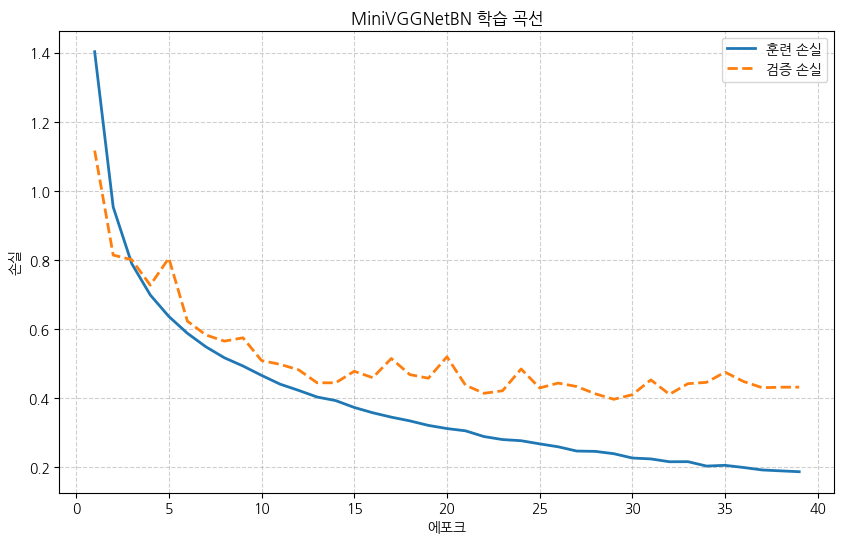

In [13]:
# 참고 - MiniVGGNetBN 모델 학습
import torch.optim as optim

# 모델마다 결과 재현을 위해 학습 전에 시드 고정
common.set_seed(SEED, deterministic=True)

# MiniVGGNetBN 모델 객체를 생성하고 학습 장치로 이동
model_vggbn = MiniVGGNetBN()
model_vggbn.to(device)                               

# 옵티마이저
optimizer = optim.Adam(model_vggbn.parameters(), lr=LR)

# 모델 학습
print('MiniVGGNetBN 학습')
log_vggbn = train_with_early_stopping(
    model_vggbn, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE, device
)

log_vggbn.plot(title='MiniVGGNetBN 학습 곡선', y_label='손실')

In [14]:
# 참고 - MiniVGGNetBN 모델의 평가

train_loss, train_acc = evaluate(model_vggbn, train_evaluate_loader, criterion, device)
test_loss, test_acc = evaluate(model_vggbn, test_loader, criterion, device)
print('MiniVGGNetBN 모델 평가(훈련 데이터셋)')
print(f'훈련 손실: {train_loss:.4f}, 정확도: {train_acc * 100:.2f}%')
print(f'MiniVGGNetBN 모델 평가(평가 데이터셋)')
print(f'평가 손실: {test_loss:.4f}, 정확도: {test_acc * 100:.2f}%')


MiniVGGNetBN 모델 평가(훈련 데이터셋)
훈련 손실: 0.1917, 정확도: 93.19%
MiniVGGNetBN 모델 평가(평가 데이터셋)
평가 손실: 0.4282, 정확도: 86.27%


## [코드 8-5] 계층의 입력·출력 데이터의 평균과 표준편차를 출력하는 훅 함수

`register_forward_hook()` 으로 등록할 콜백 함수다. 모듈(계층), 입력 텐서, 출력 텐서 순서로 인자를 받는다. 여러 계층의 출력이 입력될 수 있으므로 입력은 튜플 형태이며, 연결된 이전 계층이 하나뿐이므로 `inputs[0]` 만 쓴다.

In [15]:
###############################################################################
# 코드 8-5 - 계층의 입력, 출력 데이터의 평균과 표준편차를 출력하는 훅 함수
###############################################################################
# 계층 통과 전후 데이터의 평균과 표준편차를 계산해 출력하는 함수
#     register_forward_hook 메서드로 훅을 등록하는 경우의 인자
#         module: 훅을 등록할 계층
#         inputs: 계층으로 입력된 텐서
#             여러 계층의 출력이 입력될 수 있으므로 튜플 형태
#         output: 계층이 출력하는 텐서 
def data_inspect_hook(module, inputs, output):
    # 계층 입력 데이터의 평균과 표준편차
    # 이전 계층이 하나뿐이므로 inputs[0]만 계산
    input_mean = inputs[0].mean().item()
    input_std = inputs[0].std().item()
    # 계층 출력 데이터의 평균과 표준편차
    output_mean = output.mean().item()
    output_std = output.std().item()
    # 계층 통과 전후의 평균과 표준편차 출력
    print(f'   {input_mean:.2f}({input_std:.2f}) -> '
          f'{output_mean:.2f}({output_std:.2f})')

## [코드 8-6] 모델의 첫 번째 배치 정규화 계층에 훅 등록하기

`nn.Sequential` 로 만든 모듈은 속성 변수로 접근할 수 없으므로 순서 기준 인덱싱으로 접근한다. 첫 번째 VGG 블록(`features[0]`) 의 두 번째 계층 (`features[0][1]`, BatchNorm2d) 에 훅을 등록한다.

In [16]:
###############################################################################
# 코드 8-6 - 모델의 첫 번째 배치 정규화 계층에 훅 등록하기
###############################################################################
# 결과 재현을 위한 시드 고정
torch.manual_seed(SEED)

# 훅을 등록할 모델 (학습하지 않은 새 모델 생성)
model = MiniVGGNetBN()

# 훅을 추가할 계층: model.features의 첫 번째 VGG 블록의 두 번째 계층
target_layer = model.features[0][1]     # BatchNorm2d 계층

# 훅 등록: register_forward_hook
#     순전파에서 데이터가 등록한 계층을 통과할 때 등록한 훅 함수 호출
hook_handle = target_layer.register_forward_hook(data_inspect_hook)

## [코드 8-7] 모드에 따른 배치 정규화 훅 실행 결과

학습 모드에서는 배치 단위로 평균 0, 표준편차 1 이 되도록 정규화하지만, 평가 모드에서는 배치와 무관하게 훈련 데이터 전체의 통계로 정규화한다.

In [17]:
###############################################################################
# 코드 8-7 - 모드에 따른 배치 정규화 훅 실행 결과
###############################################################################
# 데이터가 target_layer를 지날 때 data_inspect_hook() 함수가 자동 실행
#     배치 정규화 계층 통과 전후의 평균과 표준편차 출력
print('배치 정규화 전 평균(표준편차) --> 배치 정규화 후 평균(표준편차)')
print('학습 모드에서의 출력')
model.train()
for i, (inputs, labels) in enumerate(train_loader):
    # 5개의 배치 입력에 대해서 확인
    if i == 5:
        break    
    output = model(inputs)              # 순전파 발생 -> 훅 실행

# 훅은 모드와 무관하게 작동하므로 평가 모드에서도 출력하지만,
# 배치 정규화는 모드에 따라 다르게 동작하므로 출력 결과는 다름
print('평가 모드에서의 출력')
model.eval()
#for inputs, labels in train_loader:
for i, (inputs, labels) in enumerate(train_loader):
    # 5개의 배치 입력에 대해서 확인    
    if i == 5:
        break
    output = model(inputs)

배치 정규화 전 평균(표준편차) --> 배치 정규화 후 평균(표준편차)
학습 모드에서의 출력
   0.02(0.32) -> 0.00(1.00)
   0.03(0.32) -> -0.00(1.00)
   0.02(0.33) -> 0.00(1.00)
   0.02(0.33) -> -0.00(1.00)
   0.02(0.34) -> -0.00(1.00)
평가 모드에서의 출력
   0.02(0.33) -> 0.02(0.39)
   0.03(0.32) -> 0.02(0.38)
   0.02(0.33) -> 0.02(0.39)
   0.03(0.33) -> 0.02(0.40)
   0.02(0.33) -> 0.01(0.40)


## [코드 8-8] 등록한 훅 제거

남아 있는 훅은 조건이 맞으면 자동 실행되어 모델 동작에 영향을 주므로, 더 이상 필요 없는 훅은 핸들의 `remove()` 메서드로 제거한다.

In [18]:
###############################################################################
# 코드 8-8 - 등록한 훅 제거
###############################################################################
# 훅 핸들의 remove() 메서드로 제거
hook_handle.remove()

## [코드 8-9] 역전파로 전달된 기울기 신호의 정보를 출력하는 훅 함수

`register_full_backward_hook()` 으로 등록할 콜백 함수다. 모듈, 앞 계층으로 전달할 기울기(`grad_inputs`), 뒤 계층에서 전달된 기울기(`grad_outputs`) 순서로 인자를 받는다. 사용하지 않는 인자도 자리를 채워야 한다.

In [19]:
###############################################################################
# 코드 8-9 - 역전파로 전달된 기울기 신호의 정보를 출력하는 훅 함수
###############################################################################
# 역전파로 전달된 기울기 신호의 정보를 출력하는 훅 함수
# register_full_backward_hook 메서드로 훅을 등록하는 경우의 인자
#     module: 훅을 등록할 계층
#     grad_inputs: 앞 계층으로 전달할 기울기 신호 (튜플 형태)
#     grad_outputs: 뒤 계층에서 전달된 기울기 신호 (튜플 형태)
def gradient_hook(module, grad_inputs, grad_outputs):
    # 절댓값의 최댓값: 기울기 소실 또는 폭주 확인
    grad_max = grad_outputs[0].abs().max().item()
    # 노름: 벡터 또는 텐서의 크기 지표 (텐서의 norm() 메서드 사용)
    grad_norm = grad_outputs[0].norm().item()
    print(f'    최댓값: {grad_max:.6f}, 노름: {grad_norm:.6f}')

## [코드 8-10] 훅을 통한 기울기 신호 검사

MiniVGGNetBN 의 첫 번째·세 번째·여섯 번째(마지막) 합성곱 계층에 훅을 등록한 뒤 역전파를 발생시킨다. 역전파에 반응하므로 출력층에 가까운 마지막 합성곱 계층의 값이 먼저 출력된다. 훅 핸들을 `handles` 리스트에 모아 일괄 제거하는 패턴을 사용한다.

> `requires_grad=False` 인 이미지 텐서를 입력받는 첫 번째 합성곱 계층은 `grad_inputs` 가 None 이므로 경고가 출력될 수 있다. 예제에서는 `grad_outputs` 만 사용하므로 무시해도 된다.

In [20]:
###############################################################################
# 코드 8-10 - 훅을 통한 기울기 신호 검사
###############################################################################
# 검사 대상 모델: MiniVGGNetBN
torch.manual_seed(SEED)
model_vggbn = MiniVGGNetBN()

# 훅을 등록할 계층 리스트
# model_vggbn.features[i][j]: (i + 1)번째 VGG 블록의 (j + 1)번째 계층
conv_layers = [
    model_vggbn.features[0][0],     # 모델 전체의 첫 번째 합성곱 계층
    model_vggbn.features[1][0],     # 모델 전체의 세 번째 합성곱 계층
    model_vggbn.features[2][3]      # 모델 전체의 마지막 합성곱 계층
]

# 역전파에서 기울기가 계산될 때 호출되는 훅 등록(register_full_backward_hook)
# 훅 핸들을 리스트에 모으면 루프를 사용해 훅 일괄 제거 가능
handles = []
for layer in conv_layers:
    handle = layer.register_full_backward_hook(gradient_hook)
    handles.append(handle)

# 첫 번째 배치의 역전파만 확인(최적화 없이 backward()만으로 역전파 진행)
inputs, targets = next(iter(train_loader))
criterion = nn.CrossEntropyLoss()

print('모델 MiniVGGNetBN')
model_vggbn.train()
output = model_vggbn(inputs)
loss = criterion(output, targets)
loss.backward()

# 리스트에 저장해 둔 훅 핸들을 사용해 훅 일괄 제거
for handle in handles:
    handle.remove()

모델 MiniVGGNetBN
    최댓값: 0.000594, 노름: 0.057272
    최댓값: 0.000491, 노름: 0.077910
    최댓값: 0.001943, 노름: 0.240853


/tmp/ipykernel_17180/3483218823.py:31: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


## [표 8-5] 합성곱 계층의 위치별 노름의 변화

MiniAlexNet, MiniVGGNet, MiniVGGNetBN 세 모델의 일부 합성곱 계층에 훅을 등록해 기울기 노름을 측정한다. 배치 정규화가 없는 MiniVGGNet 은 입력에 가까운 계층일수록 노름이 크게 줄어드는(기울기 소실) 경향을, MiniVGGNetBN 은 그런 경향이 사라짐을 확인할 수 있다.

In [21]:
# 참고 - 비교를 위한 MiniAlexNet 모델과 MiniVGGNet 모델 (8-1절과 동일한 모델)

# ConvBlock: 합성곱, ReLU 활성화 함수, 최대 풀링으로 구성된 합성곱 블록
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels,
                 kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.conv_block(x)

# MiniAlexNet: AlexNet 전략을 차용한 CIFAR-10 분류기
# 큰 합성곱 필터를 앞 부분에 배치해 수용 영역을 빠르게 확장하는 합성곱 모델
class MiniAlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 5x5 필터로 수용 영역을 빠르게 확장
        self.conv_block_1 = ConvBlock(
            in_channels=3, out_channels=16,
            kernel_size=5, stride=1, padding=2,
        )                                   # (3, 32, 32) -> (16, 16, 16)
        # 3x3 필터로 특징 추출
        self.conv_block_2 = ConvBlock(
            in_channels=16, out_channels=32,
            kernel_size=3, stride=1, padding=1,
        )                                   # (16, 16, 16) -> (32, 8, 8)
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # (32, 8, 8) -> (32 * 8 * 8,)
            nn.Linear(32 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

# MiniVGGNet: VGGNet의 구조를 가진 합성곱 신경망 모델(CIFAR-10 데이터셋 분류)
#     특징 추출기: (3x3 필터 합성곱 -> 3x3 필터 합성곱 -> 최대 풀링) * 3
#     분류기: 완전 연결 계층
class MiniVGGNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 반복되는 VGG 블록을 만드는 헬퍼 함수 (내부 함수)
        def vgg_block(in_channels, out_channels):
            # VGGNet의 핵심 - 3x3 합성곱 두 번 + 풀링으로 축소
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2),
            )
        # 특징 추출기: VGG 블록을 반복해 배치
        self.features = nn.Sequential(
            vgg_block(3, 32),               # (3, 32, 32)  -> (32, 16, 16)
            vgg_block(32, 64),              #              -> (64, 8, 8)
            vgg_block(64, 128),             #              -> (128, 4, 4)
        )
        # 분류기: 특징 추출기가 추출한 특징을 사용해 분류
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # (128, 4, 4)  -> (128 * 4 * 4,)
            nn.Linear(128 * 4 * 4, 128),    #              -> (128,)
            nn.ReLU(),
            nn.Dropout(p=0.5),              # 드롭아웃 계층
            nn.Linear(128, num_classes),    #              -> (10,)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x        

In [22]:
# 참고 - [표 8-5] 세 모델의 합성곱 계층별 기울기 노름 측정
def measure_grad_norms(model, named_layers, inputs, labels):
    """named_layers: [(표시 이름, 모듈 객체), ...]."""
    norms = {name: None for name, _ in named_layers}
    handles = []

    def make_hook(name):
        def hook(module, grad_inputs, grad_outputs):
            norms[name] = grad_outputs[0].norm().item()
        return hook

    for name, layer in named_layers:
        handles.append(layer.register_full_backward_hook(make_hook(name)))
    model.train()
    criterion = nn.CrossEntropyLoss()
    output = model(inputs)
    loss = criterion(output, labels)
    loss.backward()
    for handle in handles:
        handle.remove()
    return norms


# 새 모델 세 개 생성 (같은 초기 가중치)
torch.manual_seed(SEED)
m_alex = MiniAlexNet()
torch.manual_seed(SEED)
m_vgg = MiniVGGNet()
torch.manual_seed(SEED)
m_vggbn = MiniVGGNetBN()

inputs, labels = next(iter(train_loader))

# MiniAlexNet: 합성곱 2 개
alex_norms = measure_grad_norms(m_alex, [
    ('1', m_alex.conv_block_1.conv_block[0]),
    ('마지막', m_alex.conv_block_2.conv_block[0]),
], inputs, labels)
# MiniVGGNet: 합성곱 6 개 중 1·3·마지막
vgg_norms = measure_grad_norms(m_vgg, [
    ('1', m_vgg.features[0][0]),
    ('3', m_vgg.features[1][0]),
    ('마지막', m_vgg.features[2][2]),
], inputs, labels)
# MiniVGGNetBN: 합성곱 6 개 중 1·3·마지막
vggbn_norms = measure_grad_norms(m_vggbn, [
    ('1', m_vggbn.features[0][0]),
    ('3', m_vggbn.features[1][0]),
    ('마지막', m_vggbn.features[2][3]),
], inputs, labels)

print(f'{"합성곱":>6s} | {"MiniAlexNet":>12s} | '
      f'{"MiniVGGNet":>12s} | {"MiniVGGNetBN":>12s}')
print('-' * 56)
for key in ['1', '3', '마지막']:
    def fmt(x):
        return f'{x:.6f}' if x is not None else '-'
    print(f'{key:>6s} | {fmt(alex_norms.get(key)):>12s} | '
          f'{fmt(vgg_norms.get(key)):>12s} | '
          f'{fmt(vggbn_norms.get(key)):>12s}')

/tmp/ipykernel_17180/111308057.py:18: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


   합성곱 |  MiniAlexNet |   MiniVGGNet | MiniVGGNetBN
--------------------------------------------------------
     1 |     0.010262 |     0.000273 |     0.240853
     3 |            - |     0.001368 |     0.077910
   마지막 |     0.022127 |     0.020847 |     0.057272


## 정리

- 배치 정규화는 각 계층의 출력을 배치 단위로 평균 0, 표준편차 1 로 규격화한 뒤 학습 가능한 감마·베타로 크기와 위치를 조정한다.
- 배치 정규화를 추가한 MiniVGGNetBN 은 더 적은 에포크로 수렴하고 분류 정확도와 일반화 성능이 함께 개선된다([표 8-3]).
- 파이토치 훅은 모델을 수정하지 않고 계층의 입출력·기울기를 들여다보는 도구다. 순전파 훅으로 배치 정규화 전후 분포를, 역전파 훅으로 계층별 기울기 노름을 관찰해 배치 정규화가 기울기 소실을 완화함을 확인했다.

In [23]:
sdsfs
#--- 추가 테스트 ---#
class MiniVGGNetBN_2(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 반복되는 VGG 블록을 만드는 헬퍼 함수
        def vgg_block(in_channels, out_channels):
            # 합성곱 계층과 활성화 계층 사이에 배치 정규화 계층 추가
            return nn.Sequential(
                # 배치 정규화의 베타 파라미터가 편향을 대체 (bias=False)
                nn.Conv2d(
                    in_channels, out_channels, kernel_size=3, padding=1,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),       # <- 추가
                nn.ReLU(),
                nn.Conv2d(
                    out_channels, out_channels, kernel_size=3, padding=1,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),       # <- 추가
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2),
            )
        # 특징 추출기 - VGG 블록을 반복해 배치
        self.features = nn.Sequential(
            vgg_block(3, 32),               # (3, 32, 32)  -> (32, 16, 16)
            vgg_block(32, 64),              # (32, 16, 16) -> (64, 8, 8)
            vgg_block(64, 128),             # (64, 8, 8)   -> (128, 4, 4)
        )
        # 분류기 - 특징을 사용해 분류 (드롭아웃 계층 제거)
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # (128, 4, 4) -> (128 * 4 * 4,)
            nn.Linear(128 * 4 * 4, 128),    # -> (128,)
            nn.ReLU(),
            nn.Dropout(p=0.5),              # 50% 확률로 출력을 0으로
            nn.Linear(128, num_classes),    # (128,) -> (10,)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

class MiniVGGNetBN_3(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 반복되는 VGG 블록을 만드는 헬퍼 함수
        def vgg_block(in_channels, out_channels):
            # 합성곱 계층과 활성화 계층 사이에 배치 정규화 계층 추가
            return nn.Sequential(
                # 배치 정규화의 베타 파라미터가 편향을 대체 (bias=False)
                nn.Conv2d(
                    in_channels, out_channels, kernel_size=3, padding=1,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),       # <- 추가
                nn.ReLU(),
                nn.Conv2d(
                    out_channels, out_channels, kernel_size=3, padding=1,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),       # <- 추가
                nn.ReLU(),
                nn.Conv2d(
                    out_channels, out_channels, kernel_size=3, padding=1,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),       # <- 추가
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2),
            )
        # 특징 추출기 - VGG 블록을 반복해 배치
        self.features = nn.Sequential(
            vgg_block(3, 32),               # (3, 32, 32)  -> (32, 16, 16)
            vgg_block(32, 64),              # (32, 16, 16) -> (64, 8, 8)
            vgg_block(64, 128),             # (64, 8, 8)   -> (128, 4, 4)
        )
        # 분류기 - 특징을 사용해 분류 (드롭아웃 계층 제거)
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # (128, 4, 4) -> (128 * 4 * 4,)
            nn.Linear(128 * 4 * 4, 128),    # -> (128,)
            nn.ReLU(),
            nn.Linear(128, num_classes),    # (128,) -> (10,)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    
class MiniVGGNetBN_4(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 반복되는 VGG 블록을 만드는 헬퍼 함수
        def vgg_block(in_channels, out_channels):
            # 합성곱 계층과 활성화 계층 사이에 배치 정규화 계층 추가
            return nn.Sequential(
                # 배치 정규화의 베타 파라미터가 편향을 대체 (bias=False)
                nn.Conv2d(
                    in_channels, out_channels, kernel_size=3, padding=1,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),       # <- 추가
                nn.ReLU(),
                nn.Conv2d(
                    out_channels, out_channels, kernel_size=3, padding=1,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),       # <- 추가
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2),
            )
        # 특징 추출기 - VGG 블록을 반복해 배치
        self.features = nn.Sequential(
            vgg_block(3, 32),               # (3, 32, 32)  -> (32, 16, 16)
            vgg_block(32, 64),              # (32, 16, 16) -> (64, 8, 8)
            vgg_block(64, 128),             # (64, 8, 8)   -> (128, 4, 4)
            vgg_block(128, 256),             # (128, 4, 4) -> (256, 2, 2)

        )
        # 분류기 - 특징을 사용해 분류 (드롭아웃 계층 제거)
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # (256, 2, 2) -> (256 * 2 * 2,)
            nn.Linear(256 * 2 * 2, 128),    # -> (128,)
            nn.ReLU(),
            nn.Linear(128, num_classes),    # (128,) -> (10,)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    
class MiniVGGNetBN_5(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 반복되는 VGG 블록을 만드는 헬퍼 함수
        def vgg_block(in_channels, out_channels):
            # 합성곱 계층과 활성화 계층 사이에 배치 정규화 계층 추가
            return nn.Sequential(
                # 배치 정규화의 베타 파라미터가 편향을 대체 (bias=False)
                nn.Conv2d(
                    in_channels, out_channels, kernel_size=3, padding=1,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),       # <- 추가
                nn.ReLU(),
                nn.Conv2d(
                    out_channels, out_channels, kernel_size=3, padding=1,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),       # <- 추가
                nn.ReLU(),
                nn.Conv2d(
                    out_channels, out_channels, kernel_size=3, padding=1,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),       # <- 추가
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2),
            )
        # 특징 추출기 - VGG 블록을 반복해 배치
        self.features = nn.Sequential(
            vgg_block(3, 32),               # (3, 32, 32)  -> (32, 16, 16)
            vgg_block(32, 64),              # (32, 16, 16) -> (64, 8, 8)
            vgg_block(64, 128),             # (64, 8, 8)   -> (128, 4, 4)
        )
        # 분류기 - 특징을 사용해 분류 (드롭아웃 계층 제거)
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # (128, 4, 4) -> (128 * 4 * 4,)
            nn.Linear(128 * 4 * 4, 128),    # -> (128,)
            nn.ReLU(),
            nn.Dropout(p=0.5),              # 50% 확률로 출력을 0으로
            nn.Linear(128, num_classes),    # (128,) -> (10,)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

EPOCHS = 50
torch.manual_seed(SEED)
model_vgg_2 = MiniVGGNetBN_2().to(device)
optimizer = optim.Adam(model_vgg_2.parameters(), lr=LR)
print('=== MiniVGGNetBN_2 학습 ===')
log_vgg_2 = train_with_early_stopping(
    model_vgg_2, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE, device,
)
log_vgg_2.plot(title='MiniVGGNetBN_2 학습 곡선', y_label='손실')    
result_vgg_2 = collect_result('MiniVGGNetBN_2', model_vgg_2, log_vgg_2)
torch.manual_seed(SEED)
model_vgg_3 = MiniVGGNetBN_3().to(device)
optimizer = optim.Adam(model_vgg_3.parameters(), lr=LR)
print('=== MiniVGGNetBN_3 학습 ===')
log_vgg_3 = train_with_early_stopping(
    model_vgg_3, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE, device,
)
log_vgg_3.plot(title='MiniVGGNetBN_3 학습 곡선', y_label='손실')    
result_vgg_3 = collect_result('MiniVGGNetBN_3', model_vgg_3, log_vgg_3)
torch.manual_seed(SEED)
model_vgg_4 = MiniVGGNetBN_4().to(device)
optimizer = optim.Adam(model_vgg_4.parameters(), lr=LR)
print('=== MiniVGGNetBN_4 학습 ===')
log_vgg_4 = train_with_early_stopping(
    model_vgg_4, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE, device,
)
log_vgg_4.plot(title='MiniVGGNetBN_4 학습 곡선', y_label='손실')    
result_vgg_4 = collect_result('MiniVGGNetBN_4', model_vgg_4, log_vgg_4)
torch.manual_seed(SEED)
model_vgg_5 = MiniVGGNetBN_5().to(device)
optimizer = optim.Adam(model_vgg_5.parameters(), lr=LR)
print('=== MiniVGGNetBN_5 학습 ===')
log_vgg_5 = train_with_early_stopping(
    model_vgg_5, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE, device,
)
log_vgg_5.plot(title='MiniVGGNetBN_5 학습 곡선', y_label='손실')    
result_vgg_5 = collect_result('MiniVGGNetBN_5', model_vgg_5, log_vgg_5)



=== MiniVGGNetBN_2 학습 ===
epoch    훈련 손실    검증 손실    정확도(%)     시간
 1/50       1.6941       1.3028       53.09%     0:11
 2/50       1.3323       1.1578       56.76%     0:23
 3/50       1.1779       0.9830       65.35%     0:34
 4/50       1.0747       0.8717       68.80%     0:45
 5/50       0.9955       0.8482       70.09%     0:56
 6/50       0.9498       0.7351       73.93%     1:07
 7/50       0.8954       0.8108       71.28%     1:19
 8/50       0.8512       0.7096       74.45%     1:30
 9/50       0.8204       0.7366       73.76%     1:41
10/50       0.7847       0.6333       77.67%     1:52
11/50       0.7562       0.5761       80.50%     2:04
12/50       0.7303       0.5775       79.99%     2:15
13/50       0.7009       0.6384       78.53%     2:26
14/50       0.6844       0.5264       81.55%     2:37
15/50       0.6533       0.6346       78.38%     2:48
16/50       0.6448       0.5941       80.09%     3:00
17/50       0.6191       0.5549       81.17%     3:11
18/50       0.6

KeyboardInterrupt: 

In [ ]:
# 참고 - [표 8-2] 결과 정리
def print_result_table(results, label_width=12):
    header = (f'{"모델":>{label_width}s} | {"최적":>4s} | '
             f'{"전체(초)":>8s} | {"에포크당":>8s} | '
             f'{"훈련손실":>8s} | {"검증손실":>8s} | '
             f'{"훈련%":>6s} | {"평가%":>6s}')
    print(header)
    print('-' * len(header))
    for r in results:
        print(f'{r["name"]:>{label_width}s} | {r["best_epoch"]:>4d} | '
              f'{r["elapsed"]:>8.1f} | {r["seconds_per_epoch"]:>8.1f} | '
              f'{r["train_loss"]:>8.4f} | {r["valid_loss"]:>8.4f} | '
              f'{r["train_acc"]:>5.2f}% | {r["test_acc"]:>5.2f}%')


print_result_table([result_vgg_2, result_vgg_3, result_vgg_4, result_vgg_5])

## 참고 - 클로저 형태로 정의한 훅 (각주 17)

In [ ]:
# 참고 - 클로저 형태로 정의한 훅 (각주 17)
# 콜백 함수를 직접 정의하는 대신, 정해진 서명의 훅 함수를 '반환'하는 클로저로 만들 수도 있다.
# 클로저 안에 계층 이름 같은 정보를 담아 두면, 여러 계층의 출력을 이름표와 함께 모으기 편하다.
feature_maps = {}                       # 계층 이름 -> 출력 특징 지도


def make_capture_hook(name):
    # register_forward_hook 서명(module, inputs, output)에 맞는 훅 함수를 반환
    def hook(module, inputs, output):
        feature_maps[name] = output.detach()
    return hook


model = MiniVGGNetBN()
# 첫 번째, 세 번째, 마지막(여섯 번째) 합성곱 계층에 클로저 훅을 등록
target_layers = {
    '첫 번째 합성곱': model.features[0][0],
    '세 번째 합성곱': model.features[1][0],
    '마지막 합성곱': model.features[2][3],
}
handles = [layer.register_forward_hook(make_capture_hook(name))
           for name, layer in target_layers.items()]

# 배치 하나를 통과시켜 특징 지도를 수집한 뒤 훅을 정리한다
inputs, _ = next(iter(train_loader))
model.eval()
with torch.no_grad():
    model(inputs)
for handle in handles:
    handle.remove()

for name, fmap in feature_maps.items():
    print(f'{name}: {tuple(fmap.shape)}')   # (배치, 채널, 높이, 너비)

## 참고 - 특징 지도 시각화와 저장 (연습 8-10)

In [ ]:
# 참고 - 수집한 특징 지도를 시각화하고 이미지 파일로 저장 (연습 8-10)
# viz.plot_feature_map: (C, H, W) 특징 지도를 채널별 격자로 그리고,
# 시각화 설정(viz.configure)에 따라 회색조 PNG 파일로 저장한다.
sample_index = 0                        # 배치에서 살펴볼 샘플 하나 선택
for name, fmap in feature_maps.items():
    # fmap[sample_index]: (C, H, W) - 앞 8개 채널만 골라 시각화·저장
    viz.plot_feature_map(
        fmap[sample_index][:8], title=f'{name} 계층의 특징 지도(앞 8개 채널)',
    )